# Getting Started

We'll start by merging all of our 2025 datasets into one JSON file, so we can work with all of our data. This might take up a little bit and a good amount of space, so ensure your device has enough storage!

In [48]:
# import json

# # List of files to merge
# files = [
#     'Zillow-March2025-dataset_part0.json',
#     'Zillow-March2025-dataset_part1.json',
#     'Zillow-March2025-dataset_part2.json',
#     'Zillow-March2025-dataset_part3.json'
# ]

# merged_data = []

# # Read and combine all data
# for file in files:
#     with open(file, 'r') as f:
#         data = json.load(f)
#         merged_data.extend(data)  # Assumes each file contains a list

# # Write to a new merged JSON file
# with open('Zillow-Combined.json', 'w') as f:
#     json.dump(merged_data, f, indent=2)

Now that we have our combined datasets, we'll run through it and select our relevant columns.

In [49]:
import pandas as pd

# Replace with your actual path if needed
file_path = 'Zillow-Combined.json' # combined JSON file of 2025 data

# Load JSON file
df = pd.read_json(file_path)

df['is_FSBA'] = df['listing_sub_type'].apply(lambda x: x.get('is_FSBA'))
df['is_FSBO'] = df['listing_sub_type'].apply(lambda x: x.get('is_FSBO'))
df['is_comingSoon'] = df['listing_sub_type'].apply(lambda x: x.get('is_comingSoon'))
df['address'] = df['address'].apply(lambda x: x['streetAddress'])

df = df[['zpid', 'city', 'lastSoldPrice', 'price', 'zestimate', 'longitude', 'latitude', 'homeType', 'livingAreaValue', 'livingAreaUnitsShort', 
         'dateSold', 'dateSoldString', 'yearBuilt', 'bedrooms', 'bathrooms', 'is_FSBO', 'is_FSBA', 'is_comingSoon', 'address']] 

df.head(10)

,zpid,city,lastSoldPrice,price,zestimate,longitude,latitude,homeType,livingAreaValue,livingAreaUnitsShort,dateSold,dateSoldString,yearBuilt,bedrooms,bathrooms,is_FSBO,is_FSBA,is_comingSoon,address
0,50032766.0,Carrboro,441000.0,764100,764100.0,-79.077890,35.897522,SINGLE_FAMILY,3013.0,sqft,6.859296e+11,1991-09-27,1991.0,5.0,2.5,False,False,False,302 Orchard Ln #92
1,50037322.0,Chapel Hill,547500.0,829100,NaN,-79.057396,35.907510,APARTMENT,3217.0,sqft,1.175731e+12,2007-04-05,1927.0,8.0,6.0,False,False,False,232 McCauley St UNIT A
2,251696953.0,Chapel Hill,NaN,965600,965600.0,-79.143480,35.960842,SINGLE_FAMILY,3009.0,sqft,NaN,,1997.0,4.0,3.5,False,False,False,2034 Foxwood Farm Trl
3,251557517.0,Chapel Hill,NaN,453400,453400.0,-79.179276,35.894210,SINGLE_FAMILY,1658.0,sqft,NaN,,1992.0,4.0,2.0,False,False,False,1509 Partridgeberry Rd #A
4,50037263.0,Chapel Hill,725000.0,701600,NaN,-79.057724,35.906284,APARTMENT,1120.0,sqft,1.470269e+12,2016-08-04,1942.0,2.0,1.0,False,False,False,308 Ransom St
5,49996513.0,Chapel Hill,115000.0,254200,254200.0,-79.010040,35.897545,CONDO,970.0,sqft,1.404778e+12,2014-07-08,1984.0,2.0,2.0,False,False,False,298 Summerwalk Cir
6,50051487.0,Chapel Hill,599000.0,946800,946800.0,-79.029050,35.956764,SINGLE_FAMILY,3242.0,sqft,9.410688e+11,1999-10-28,1991.0,5.0,3.0,False,False,False,104 Overlook Pt
7,50042393.0,Chapel Hill,725000.0,1222800,1222800.0,-79.006140,35.931885,SINGLE_FAMILY,2700.0,sqft,1.561594e+12,2019-06-27,1987.0,5.0,3.0,False,False,False,101 Nottingham Dr
8,50041489.0,Chapel Hill,260000.0,414900,414900.0,-79.018630,35.946020,TOWNHOUSE,1456.0,sqft,1.529885e+12,2018-06-25,1996.0,3.0,2.0,False,False,False,201 McGregor Dr #A
9,50052079.0,Chapel Hill,295000.0,497800,497800.0,-79.016800,35.953910,SINGLE_FAMILY,1620.0,sqft,1.535674e+12,2018-08-31,1989.0,3.0,2.0,False,False,False,101 Orchard Ln UNIT 19


Comparing dateSold to dateSoldString, 'dateSold' is a Unix timestamp in milliseconds (seconds since Jan 1, 1970, multiplied by 1,000). We can now use dateSold as comparing ints/floats will be easier than working with strings.

In [50]:
print(df.shape)

(32033, 19)


# Cleaning

In [51]:
# check all livingAreaValue are in the same units
df['livingAreaUnitsShort'].value_counts(dropna=False)

livingAreaUnitsShort
sqft    28635
None     3398
Name: count, dtype: int64

In [52]:
# Check for missing values in livingAreaValue
df['livingAreaValue'].isna().sum()

np.int64(3398)

The number of NaN values from livingAreaUnitsShort matches the amount of NaN values from 'livingAreaValue', dropping missing livingAreaValue rows should also drop missing livingAreaUnitsShort

In [53]:
# dropping properties with missing livingAreaValue
df = df.dropna(subset=['livingAreaValue'])

# confirm assumption
df['livingAreaUnitsShort'].value_counts(dropna=False)

livingAreaUnitsShort
sqft    28635
Name: count, dtype: int64

Filtering zpid

In [54]:
# prompt: Filter the data frame to drop and zpid values that are NaN and show me the head

# Drop rows with NaN values in 'zpid'
df = df.dropna(subset=['zpid'])

# Preview the result
print(df.head())


          zpid         city  lastSoldPrice   price  zestimate  longitude  \
0   50032766.0     Carrboro       441000.0  764100   764100.0 -79.077890   
1   50037322.0  Chapel Hill       547500.0  829100        NaN -79.057396   
2  251696953.0  Chapel Hill            NaN  965600   965600.0 -79.143480   
3  251557517.0  Chapel Hill            NaN  453400   453400.0 -79.179276   
4   50037263.0  Chapel Hill       725000.0  701600        NaN -79.057724   

    latitude       homeType  livingAreaValue livingAreaUnitsShort  \
0  35.897522  SINGLE_FAMILY           3013.0                 sqft   
1  35.907510      APARTMENT           3217.0                 sqft   
2  35.960842  SINGLE_FAMILY           3009.0                 sqft   
3  35.894210  SINGLE_FAMILY           1658.0                 sqft   
4  35.906284      APARTMENT           1120.0                 sqft   

       dateSold dateSoldString  yearBuilt  bedrooms  bathrooms  is_FSBO  \
0  6.859296e+11     1991-09-27     1991.0       5.0  

Drop any cities that are not Chapel Hill or Carrboro

In [55]:
# prompt: Drop any city value that is not Carrboro or Chapel Hill

# Drop any cities that are not Chapel Hill or Carrboro
df = df[df['city'].isin(['Chapel Hill', 'Carrboro'])]

# Preview the result
print(df.head())


          zpid         city  lastSoldPrice   price  zestimate  longitude  \
0   50032766.0     Carrboro       441000.0  764100   764100.0 -79.077890   
1   50037322.0  Chapel Hill       547500.0  829100        NaN -79.057396   
2  251696953.0  Chapel Hill            NaN  965600   965600.0 -79.143480   
3  251557517.0  Chapel Hill            NaN  453400   453400.0 -79.179276   
4   50037263.0  Chapel Hill       725000.0  701600        NaN -79.057724   

    latitude       homeType  livingAreaValue livingAreaUnitsShort  \
0  35.897522  SINGLE_FAMILY           3013.0                 sqft   
1  35.907510      APARTMENT           3217.0                 sqft   
2  35.960842  SINGLE_FAMILY           3009.0                 sqft   
3  35.894210  SINGLE_FAMILY           1658.0                 sqft   
4  35.906284      APARTMENT           1120.0                 sqft   

       dateSold dateSoldString  yearBuilt  bedrooms  bathrooms  is_FSBO  \
0  6.859296e+11     1991-09-27     1991.0       5.0  

Drop any latitude value that is less than 35.85° N or greater than 36.00° N

In [56]:
# prompt: Drop any value latitude value that is less than 35.85° N or greater than 36.00° N

# Drop any value latitude value that is less than 35.85° N or greater than 36.00° N
df = df[(df['latitude'] >= 35.85) & (df['latitude'] <= 36.00)]

# Preview the result
print(df.head())


          zpid         city  lastSoldPrice   price  zestimate  longitude  \
0   50032766.0     Carrboro       441000.0  764100   764100.0 -79.077890   
1   50037322.0  Chapel Hill       547500.0  829100        NaN -79.057396   
2  251696953.0  Chapel Hill            NaN  965600   965600.0 -79.143480   
3  251557517.0  Chapel Hill            NaN  453400   453400.0 -79.179276   
4   50037263.0  Chapel Hill       725000.0  701600        NaN -79.057724   

    latitude       homeType  livingAreaValue livingAreaUnitsShort  \
0  35.897522  SINGLE_FAMILY           3013.0                 sqft   
1  35.907510      APARTMENT           3217.0                 sqft   
2  35.960842  SINGLE_FAMILY           3009.0                 sqft   
3  35.894210  SINGLE_FAMILY           1658.0                 sqft   
4  35.906284      APARTMENT           1120.0                 sqft   

       dateSold dateSoldString  yearBuilt  bedrooms  bathrooms  is_FSBO  \
0  6.859296e+11     1991-09-27     1991.0       5.0  

Drop any longitude value that is less than -79.15° W or greater than -78.95° W

In [57]:
# prompt: Drop any longitude value that is less than -79.15° W or greater than -78.95° W

# Drop any longitude value that is less than -79.15° W or greater than -78.95° W
df = df[(df['longitude'] >= -79.15) & (df['longitude'] <= -78.95)]

# Preview the result
print(df.head())


          zpid         city  lastSoldPrice   price  zestimate  longitude  \
0   50032766.0     Carrboro       441000.0  764100   764100.0 -79.077890   
1   50037322.0  Chapel Hill       547500.0  829100        NaN -79.057396   
2  251696953.0  Chapel Hill            NaN  965600   965600.0 -79.143480   
4   50037263.0  Chapel Hill       725000.0  701600        NaN -79.057724   
5   49996513.0  Chapel Hill       115000.0  254200   254200.0 -79.010040   

    latitude       homeType  livingAreaValue livingAreaUnitsShort  \
0  35.897522  SINGLE_FAMILY           3013.0                 sqft   
1  35.907510      APARTMENT           3217.0                 sqft   
2  35.960842  SINGLE_FAMILY           3009.0                 sqft   
4  35.906284      APARTMENT           1120.0                 sqft   
5  35.897545          CONDO            970.0                 sqft   

       dateSold dateSoldString  yearBuilt  bedrooms  bathrooms  is_FSBO  \
0  6.859296e+11     1991-09-27     1991.0       5.0  

In [58]:
# check number of homeTypes -- some homeTypes cannot be flipped (e.g. apartment, condo, townhouse etc.)
df['homeType'].value_counts(dropna=False)

homeType
SINGLE_FAMILY        17600
CONDO                 2478
TOWNHOUSE             2344
APARTMENT             1285
MULTI_FAMILY           350
MANUFACTURED           152
LOT                     98
HOME_TYPE_UNKNOWN       83
Name: count, dtype: int64

Drop any homeType that is NOT a single-family or multi-family home

In [59]:
# prompt: Drop any homeType that is NOT a SINGLE_FAMILY

# Drop any homeType that is NOT a SINGLE_FAMILY or MULTI_FAMILY
df = df[df['homeType'].isin(['SINGLE_FAMILY', 'MULTI_FAMILY'])]

# Preview the result
print(df.head())
print(df.shape)


          zpid         city  lastSoldPrice    price  zestimate  longitude  \
0   50032766.0     Carrboro       441000.0   764100   764100.0  -79.07789   
2  251696953.0  Chapel Hill            NaN   965600   965600.0  -79.14348   
6   50051487.0  Chapel Hill       599000.0   946800   946800.0  -79.02905   
7   50042393.0  Chapel Hill       725000.0  1222800  1222800.0  -79.00614   
9   50052079.0  Chapel Hill       295000.0   497800   497800.0  -79.01680   

    latitude       homeType  livingAreaValue livingAreaUnitsShort  \
0  35.897522  SINGLE_FAMILY           3013.0                 sqft   
2  35.960842  SINGLE_FAMILY           3009.0                 sqft   
6  35.956764  SINGLE_FAMILY           3242.0                 sqft   
7  35.931885  SINGLE_FAMILY           2700.0                 sqft   
9  35.953910  SINGLE_FAMILY           1620.0                 sqft   

       dateSold dateSoldString  yearBuilt  bedrooms  bathrooms  is_FSBO  \
0  6.859296e+11     1991-09-27     1991.0      

In [60]:
# drop rows where both bathrooms and bedrooms are NaN
df = df.dropna(subset=['bathrooms', 'bedrooms'], how='all')

Drop properties where price, zestimate, lastSoldPrice are all 0, no real way to calculate listing value.

In [61]:
((df['price'] == 0) &
 (df['zestimate'].isna()) &
 (df['lastSoldPrice'].isna())).sum()

np.int64(10)

In [62]:
# Drop rows where price is 0 and both zestimate and lastSoldPrice are NaN
df = df[~((df['price'] == 0) &
          (df['zestimate'].isna()) &
          (df['lastSoldPrice'].isna()))]
print(df.shape)

(17509, 19)


In [63]:
# prompt: write some code to impute NaN values in columns with numbers with the median value of that column

# ... (Your existing code)

# Impute NaN values in numerical columns with the median
numerical_cols = ['lastSoldPrice', 'price', 'zestimate', 'longitude', 'latitude', 'livingAreaValue', 'yearBuilt', 'bedrooms', 'bathrooms']
for col in numerical_cols:
    if pd.api.types.is_numeric_dtype(df[col]):  # Check if the column is numeric
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# ... (Rest of your code)
df.head()

,zpid,city,lastSoldPrice,price,zestimate,longitude,latitude,homeType,livingAreaValue,livingAreaUnitsShort,dateSold,dateSoldString,yearBuilt,bedrooms,bathrooms,is_FSBO,is_FSBA,is_comingSoon,address
0,50032766.0,Carrboro,441000.0,764100,764100.0,-79.07789,35.897522,SINGLE_FAMILY,3013.0,sqft,6.859296e+11,1991-09-27,1991.0,5.0,2.5,False,False,False,302 Orchard Ln #92
2,251696953.0,Chapel Hill,405000.0,965600,965600.0,-79.14348,35.960842,SINGLE_FAMILY,3009.0,sqft,NaN,,1997.0,4.0,3.5,False,False,False,2034 Foxwood Farm Trl
6,50051487.0,Chapel Hill,599000.0,946800,946800.0,-79.02905,35.956764,SINGLE_FAMILY,3242.0,sqft,9.410688e+11,1999-10-28,1991.0,5.0,3.0,False,False,False,104 Overlook Pt
7,50042393.0,Chapel Hill,725000.0,1222800,1222800.0,-79.00614,35.931885,SINGLE_FAMILY,2700.0,sqft,1.561594e+12,2019-06-27,1987.0,5.0,3.0,False,False,False,101 Nottingham Dr
9,50052079.0,Chapel Hill,295000.0,497800,497800.0,-79.01680,35.953910,SINGLE_FAMILY,1620.0,sqft,1.535674e+12,2018-08-31,1989.0,3.0,2.0,False,False,False,101 Orchard Ln UNIT 19


In [64]:
# prompt: add code to one hot encode the house type (can be single family or multi family) and one hot encode the city (can be chapel hill or carrboro). Have only one column for chapel hill and one column for single family. Instead of inputting true or false input 1 or 0

# One-hot encode 'homeType'
df['single_family'] = (df['homeType'] == 'SINGLE_FAMILY').astype(int)

# One-hot encode 'city'
df['chapel_hill'] = (df['city'] == 'Chapel Hill').astype(int)

# Drop the original 'homeType' and 'city' columns
df = df.drop(['homeType', 'city'], axis=1)


our final cleaned dataframe:

In [65]:
df_clean = df.copy()
df_clean

,zpid,lastSoldPrice,price,zestimate,longitude,latitude,livingAreaValue,livingAreaUnitsShort,dateSold,dateSoldString,yearBuilt,bedrooms,bathrooms,is_FSBO,is_FSBA,is_comingSoon,address,single_family,chapel_hill
0,50032766.0,441000.0,764100,764100.0,-79.077890,35.897522,3013.0,sqft,6.859296e+11,1991-09-27,1991.0,5.0,2.5,False,False,False,302 Orchard Ln #92,1,0
2,251696953.0,405000.0,965600,965600.0,-79.143480,35.960842,3009.0,sqft,NaN,,1997.0,4.0,3.5,False,False,False,2034 Foxwood Farm Trl,1,1
6,50051487.0,599000.0,946800,946800.0,-79.029050,35.956764,3242.0,sqft,9.410688e+11,1999-10-28,1991.0,5.0,3.0,False,False,False,104 Overlook Pt,1,1
7,50042393.0,725000.0,1222800,1222800.0,-79.006140,35.931885,2700.0,sqft,1.561594e+12,2019-06-27,1987.0,5.0,3.0,False,False,False,101 Nottingham Dr,1,1
9,50052079.0,295000.0,497800,497800.0,-79.016800,35.953910,1620.0,sqft,1.535674e+12,2018-08-31,1989.0,3.0,2.0,False,False,False,101 Orchard Ln UNIT 19,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32019,109927770.0,378000.0,729600,729600.0,-79.001730,35.889920,2292.0,sqft,1.331510e+12,2012-03-12,2012.0,3.0,2.0,False,False,False,8 Hayden Pond Ln,1,1
32024,326138108.0,405000.0,839300,839300.0,-79.005780,35.943546,2112.0,sqft,NaN,,1952.0,3.0,2.0,False,False,False,400 Old Durham Rd UNIT A,1,1
32026,88955296.0,500000.0,973300,973300.0,-79.136765,35.892380,2995.0,sqft,1.063066e+12,2003-09-09,1997.0,4.0,3.5,False,False,False,617 Bowden Rd,1,1
32028,50050282.0,44000.0,788700,788700.0,-79.037460,35.952420,3240.0,sqft,4.746816e+11,1985-01-16,1986.0,3.0,2.5,False,False,False,807 Kenmore Rd,1,1


# Clustering

In [66]:
# 1. Select columns for clustering
df_k_means = df[['longitude', 'latitude', 'single_family', 'chapel_hill', 'livingAreaValue', 'yearBuilt', 'bedrooms', 'bathrooms']].copy()

In [67]:
min_max_df = pd.DataFrame({
    'min': df_k_means.min(),
    'max': df_k_means.max()
})
print(min_max_df)

                         min           max
longitude         -79.149990     -78.97554
latitude           35.850006      35.99988
single_family       0.000000       1.00000
chapel_hill         0.000000       1.00000
livingAreaValue     0.000000  137038.00000
yearBuilt        1810.000000    2025.00000
bedrooms            0.000000      99.00000
bathrooms           0.000000     396.00000


Max of 137,038 sqft, 99 bedrooms, and 396 bathrooms? We'll use robust scaling as opposed to standard minmax scaling as minmax scaling is sensitive to outliers while robust scaling uses median and IQR, making it more suitable for datasets with outliers.

In [68]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# 2. Separate continuous and binary columns
continuous_cols = ['longitude', 'latitude', 'livingAreaValue', 'yearBuilt', 'bedrooms', 'bathrooms']
binary_cols = ['single_family', 'chapel_hill']

# 3. Apply RobustScaler only to continuous columns
scaler = MinMaxScaler()
scaled_continuous = pd.DataFrame(scaler.fit_transform(df_k_means[continuous_cols]), columns=continuous_cols, index=df_k_means.index)

# 4. Concatenate scaled continuous data with unscaled binary features
scaled_df = pd.concat([scaled_continuous, df_k_means[binary_cols]], axis=1)

# 5. Handle missing values (if any)
for col in scaled_df.columns:
    if pd.api.types.is_numeric_dtype(scaled_df[col]):
        median_val = scaled_df[col].median()
        scaled_df[col] = scaled_df[col].fillna(median_val)

# 6. Instantiate and fit KMeans
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init='auto', random_state=42)
kmeans = kmeans.fit(scaled_df)

# 7. Predict cluster labels
labels = kmeans.predict(scaled_df)
print(labels)

[2 1 0 ... 2 0 0]


In [69]:
Centers = kmeans.cluster_centers_
print(Centers)

[[0.75177565 0.51663602 0.01999369 0.79432119 0.03743702 0.00775921
  0.96262107 0.99969734]
 [0.40625504 0.66483771 0.01938659 0.84325209 0.03781717 0.00744189
  0.99750668 0.99857524]
 [0.42333277 0.25600017 0.018333   0.78873197 0.03566883 0.00699879
  0.98637911 0.91884222]]


In [70]:
# 5. Add clusters to scaled and unscaled DataFrames
scaled_df['Label'] = labels+1
df['Label'] = labels+1
scaled_df.head()

,longitude,latitude,livingAreaValue,yearBuilt,bedrooms,bathrooms,single_family,chapel_hill,Label
0,0.413299,0.317040,0.021987,0.841860,0.050505,0.006313,1,0,3
2,0.037317,0.739528,0.021957,0.869767,0.040404,0.008838,1,1,2
6,0.693265,0.712318,0.023658,0.841860,0.050505,0.007576,1,1,1
7,0.824592,0.546319,0.019703,0.823256,0.050505,0.007576,1,1,1
9,0.763485,0.693276,0.011822,0.832558,0.030303,0.005051,1,1,1


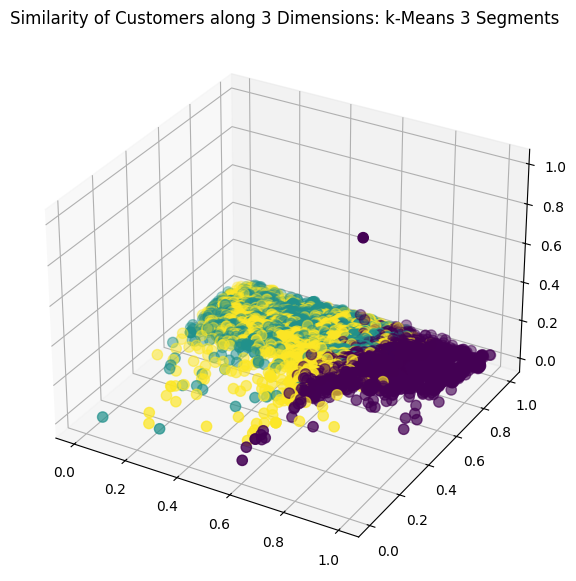

In [71]:
import matplotlib.pyplot as plt

# 2. Create Figure
fig = plt.figure()
ax = plt.axes(projection='3d')

# 3. Select dimensions for three-dimensional scattered points
dims = [0, 3, 4]

# 4. Plot the three-dimensional scatter plot
# Use .iloc to access data using column names
ax.scatter3D(scaled_df.iloc[:, dims[0]], scaled_df.iloc[:, dims[1]], scaled_df.iloc[:, dims[2]], c=scaled_df.Label, cmap='viridis', s=55)
ax.scatter(Centers[:, dims[0]], Centers[:, dims[1]], Centers[:, dims[2]], marker='*', c='red', s=400)
plt.title('Similarity of Customers along 3 Dimensions: k-Means 3 Segments')
plt.show()

In [72]:
df.head()

,zpid,lastSoldPrice,price,zestimate,longitude,latitude,livingAreaValue,livingAreaUnitsShort,dateSold,dateSoldString,yearBuilt,bedrooms,bathrooms,is_FSBO,is_FSBA,is_comingSoon,address,single_family,chapel_hill,Label
0,50032766.0,441000.0,764100,764100.0,-79.07789,35.897522,3013.0,sqft,6.859296e+11,1991-09-27,1991.0,5.0,2.5,False,False,False,302 Orchard Ln #92,1,0,3
2,251696953.0,405000.0,965600,965600.0,-79.14348,35.960842,3009.0,sqft,NaN,,1997.0,4.0,3.5,False,False,False,2034 Foxwood Farm Trl,1,1,2
6,50051487.0,599000.0,946800,946800.0,-79.02905,35.956764,3242.0,sqft,9.410688e+11,1999-10-28,1991.0,5.0,3.0,False,False,False,104 Overlook Pt,1,1,1
7,50042393.0,725000.0,1222800,1222800.0,-79.00614,35.931885,2700.0,sqft,1.561594e+12,2019-06-27,1987.0,5.0,3.0,False,False,False,101 Nottingham Dr,1,1,1
9,50052079.0,295000.0,497800,497800.0,-79.01680,35.953910,1620.0,sqft,1.535674e+12,2018-08-31,1989.0,3.0,2.0,False,False,False,101 Orchard Ln UNIT 19,1,1,1


We'll use the elbow method to confirm the optimal amount of clusters as the optimal k value should be the point at which the elbow is formed.

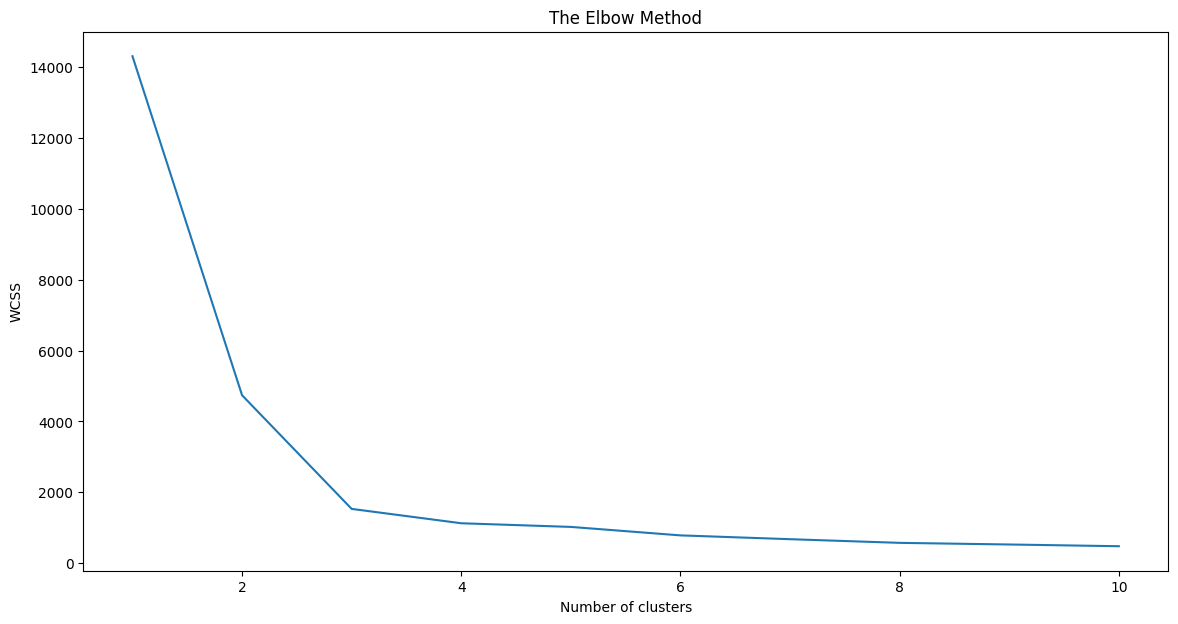

In [73]:
# 1. Import required packages
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 2. Create an empty list to hold Within Cluster Sum of Squares (WCSS)
wcss = []

# 3. Run k-means multiple times (here 11) with k = 1 to 11 and record WCSS (using .inertia_)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init = 'k-means++', max_iter = 300, n_init = "auto", random_state = 42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# 4. Plot WCSS against k in a line graph and look for 'The Elbow'
plt.rcParams['figure.figsize'] = (14, 7)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS') #within cluster sum of squares
plt.show()

Hooray! The elbow forms around 3 clusters.

In [74]:
# prompt: Write some code that will return a dictionary where each key is a neighborhoodRegion (like the column in the dataframes_plain dataframe) where each key is a neighborhoodRegion and the values are tuples containing the median home price in the neighborhoodRegion and the standard deviation for the price in that neighborhoodRegion

# dataframes_plain = pd.concat(dataframes)

def cluster_stats(df) -> dict:
  """
  Calculates the median home price and standard deviation for each neighborhood region.

  Args:
    df: A pandas DataFrame containing 'neighborhoodRegion' and 'price' columns.

  Returns:
    A dictionary where keys are neighborhood regions and values are tuples
    containing the median price and standard deviation.
  """
  cluster_stats = dict()
  visited = set()

  for cluster in df['Label']:
    if cluster is None:
      continue  # Skip to the next iteration if region or name is None

    if cluster in visited:
      continue
    visited.add(cluster)
    cluster_data = df[df['Label'] == cluster]
    median_price = cluster_data['price'].median()
    std_dev_price = cluster_data['price'].std()
    cluster_stats[cluster] = (median_price, std_dev_price)
  return cluster_stats

stats = cluster_stats(df)
stats

{3: (np.float64(706700.0), np.float64(425383.8275632342)),
 2: (np.float64(714200.0), np.float64(365206.7004163585)),
 1: (np.float64(721700.0), np.float64(601997.4853539695))}

In [75]:
# prompt: write a script that will look at each instance in the dataframes_plain dataframe that will add an indicator column such that if the price of the house is above or around the median of the price of the neighborhood put a 0 in the indicator column, 1 standard deviation below the median have a 1 in the indicator column, if its two standard deviations below put a 2 in the indicator column, etc.

import pandas as pd

def add_indicator_column(df, stats):
  """
  Adds an indicator column to the DataFrame based on house price relative to neighborhood median.

  Args:
    df: The input DataFrame with 'price' and 'Label' columns.
    stats: A dictionary containing neighborhood statistics (median price, std dev).

  Returns:
    A new DataFrame with the added 'indicator' column.
  """

  df_copy = df.copy()
  indicator_column = []

  for index, row in df_copy.iterrows():
      cluster = row['Label']
      if cluster is None:
        continue

      median_price, std_dev_price = stats[cluster]
      price = row['price']

      if std_dev_price == 0:  # Handle cases where standard deviation is zero
          if price >= median_price:
              indicator_column.append(0)
          else:
              indicator_column.append(1) # Assign 1 if price is below median when std dev is zero.
      else:
          # deviations_below = (median_price - price) / std_dev_price
          # indicator_column.append(int(deviations_below) if deviations_below >=0 else 0)
          indicator_column.append(1) if price < median_price else indicator_column.append(0)

  df_copy['indicator'] = indicator_column
  return df_copy

# Example usage (assuming dataframes_plain and stats are defined as before)
df = add_indicator_column(df, stats)
df.head()

,zpid,lastSoldPrice,price,zestimate,longitude,latitude,livingAreaValue,livingAreaUnitsShort,dateSold,dateSoldString,...,bedrooms,bathrooms,is_FSBO,is_FSBA,is_comingSoon,address,single_family,chapel_hill,Label,indicator
0,50032766.0,441000.0,764100,764100.0,-79.07789,35.897522,3013.0,sqft,6.859296e+11,1991-09-27,...,5.0,2.5,False,False,False,302 Orchard Ln #92,1,0,3,0
2,251696953.0,405000.0,965600,965600.0,-79.14348,35.960842,3009.0,sqft,NaN,,...,4.0,3.5,False,False,False,2034 Foxwood Farm Trl,1,1,2,0
6,50051487.0,599000.0,946800,946800.0,-79.02905,35.956764,3242.0,sqft,9.410688e+11,1999-10-28,...,5.0,3.0,False,False,False,104 Overlook Pt,1,1,1,0
7,50042393.0,725000.0,1222800,1222800.0,-79.00614,35.931885,2700.0,sqft,1.561594e+12,2019-06-27,...,5.0,3.0,False,False,False,101 Nottingham Dr,1,1,1,0
9,50052079.0,295000.0,497800,497800.0,-79.01680,35.953910,1620.0,sqft,1.535674e+12,2018-08-31,...,3.0,2.0,False,False,False,101 Orchard Ln UNIT 19,1,1,1,1


In [76]:
print((df['indicator']>0).sum())

8751


# Visualizing our indicator variable on a map

In [77]:
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'browser'

# Assuming df_plain has 'longitude', 'latitude', and a column for coloring
# Replace 'column_for_coloring' with the actual column name you want to use for color
fig = px.scatter_map(df,
                        lat="latitude",
                        lon="longitude",
                        #color="zestimate", # Example color column, replace as needed
                        color="indicator",
                        zoom=12,
                        height=600,
                        width=800,
                        map_style="open-street-map",
                        hover_name="zpid", # Optional: show zpid on hover
                        title="Chapel Hill Properties")
fig.update_layout(mapbox_style="carto-positron") # Optional: Change map style
fig.show()

Since our indicator has values 1-4, we can create a map displaying properties with each label. We'll use label 2 as an example.

In [78]:
# prompt: generate a map for houses only with label 2

# Assuming df is your DataFrame with 'longitude', 'latitude', and 'Label' columns.
# Filter the DataFrame to include only houses with label 2
# If you want to see other labels just change the value in the filter
df_label_2 = df[df['Label'] == 2]

# Create the map using plotly.express
import plotly.express as px


fig = px.scatter_map(df,  # or px.scatter_mapbox if you're still using that
                     lat="latitude",
                     lon="longitude",
                     color="Label",           # This maps the different label categories to different colors
                     zoom=12,
                     height=600,
                     width=800,
                     map_style="open-street-map",
                     hover_name="zpid",       # Optional
                     title="Chapel Hill Properties by Label")
fig.update_layout(mapbox_style="carto-positron")  # Optional: switch map style
fig.show()

# Finding flippable houses that are currently on sale/will soon be on sale

Using is_FSBA (for sale by agency), is_FSBO (for sale by owner), and is_comingSoon (will be listed soon), to determine which houses are/will be on sale. We also check if indicator variable is greater than 0 to check for undervalued homes (homes below their cluster's median price). Combining the two will give us a list of all houses that could possibly be looked into to flip. This will provide an example of what our model can provide.

In [79]:
filtered_onsale_df = df[
    (df['indicator'] > 0) &
    ((df['is_FSBA']) | df['is_FSBO'] | df['is_comingSoon'])
]

filtered_onsale_df

,zpid,lastSoldPrice,price,zestimate,longitude,latitude,livingAreaValue,livingAreaUnitsShort,dateSold,dateSoldString,...,bedrooms,bathrooms,is_FSBO,is_FSBA,is_comingSoon,address,single_family,chapel_hill,Label,indicator
1051,4.999688e+07,242000.0,600000,606900.0,-78.987990,35.902325,1712.0,sqft,NaN,NaN,...,3.0,2.0,False,True,False,7 Hampton Hill Pl,1,1,1,1
1602,5.003111e+07,405000.0,487500,475800.0,-79.088560,35.867775,2091.0,sqft,NaN,NaN,...,4.0,3.0,False,True,False,332 Brandywine Rd,1,1,3,1
2396,5.004155e+07,665000.0,700000,686400.0,-79.013504,35.921970,2406.0,sqft,NaN,NaN,...,3.0,3.0,False,True,False,1408 Brigham Rd,1,1,1,1
4099,5.003960e+07,64000.0,475000,723450.0,-79.043250,35.930943,2033.0,sqft,NaN,NaN,...,4.0,2.0,False,True,False,407 Granville Rd,1,1,1,1
4188,5.004052e+07,362000.0,550000,555500.0,-79.020490,35.917496,728.0,sqft,NaN,NaN,...,2.0,1.0,False,True,False,35 Rogerson Dr,1,1,1,1
4348,5.003646e+07,485000.0,595000,612800.0,-79.066475,35.904110,1750.0,sqft,NaN,NaN,...,4.0,4.0,False,True,False,105 Johnson St,0,1,3,1
4605,7.494834e+07,252000.0,559000,723450.0,-79.109726,35.858803,2193.0,sqft,NaN,NaN,...,3.0,3.0,False,True,False,300 Stonehill Rd,1,1,3,1
5036,5.004247e+07,400000.0,579000,598800.0,-79.003800,35.936270,1883.0,sqft,NaN,NaN,...,3.0,2.0,False,True,False,400 Highview Dr,1,1,1,1
5402,8.894551e+07,317100.0,450000,454000.0,-79.035230,35.923977,1172.0,sqft,NaN,NaN,...,2.0,1.0,False,True,False,1115 Valley Park Dr,1,1,1,1
5755,2.515587e+08,405000.0,550000,723450.0,-79.057340,35.929375,1380.0,sqft,NaN,NaN,...,5.0,3.0,False,True,False,123 Barclay Rd,1,1,1,1


Now we will determine which houses are actually flippable. We'll do this buy calculating a home's ARV (after repair value) by finding nearby comparable houses based on square footage, bedrooms, bathrooms, location, and yearBuilt. We then find the average price/sqft of each of these houses and multiply that by the target home's square footage. We'll be looking in a 1 mile radius and sold within the past 6 months , then 2 mile radius and sold within the past year, 3 mile radius and within 18 months, and 3 miles radius and within 2 years. 

In [80]:
from datetime import datetime
from geopy.distance import geodesic
import numpy as np
import pandas as pd

# Ensure date is in datetime format
df['dateSold_dt'] = pd.to_datetime(df['dateSoldString'], errors='coerce')
today = pd.to_datetime("today")

# Filter valid records from the full dataframe
df_valid = df[df['price'].notna() & df['livingAreaValue'].notna() & df['dateSold_dt'].notna()]

# Function to group beds/baths
def get_bed_bath_group(beds):
    if beds <= 3:
        return (1, 3, 1, 2)
    elif beds <= 6:
        return (4, 6, 2, 4)
    else:
        return (7, 99, 4, 10)

# Function to get comps
def get_comps(row, radius_miles=1, months=6):
    lat1, lon1 = row['latitude'], row['longitude']
    sqft = row['livingAreaValue']
    bed = row['bedrooms']
    bath = row['bathrooms']
    year = row['yearBuilt']

    if pd.isna(lat1) or pd.isna(lon1) or pd.isna(sqft) or pd.isna(bed) or pd.isna(bath) or pd.isna(year):
        return pd.DataFrame()

    sqft_low = sqft * 0.85
    sqft_high = sqft * 1.15
    cutoff_date = today - pd.DateOffset(months=months)
    bed_low, bed_high, bath_low, bath_high = get_bed_bath_group(bed)

    def is_close(row2):
        lat2, lon2 = row2['latitude'], row2['longitude']
        if pd.isna(lat2) or pd.isna(lon2):
            return False
        return geodesic((lat1, lon1), (lat2, lon2)).miles <= radius_miles

    nearby = df_valid[
        (df_valid['zpid'] != row['zpid']) &
        (df_valid['dateSold_dt'] >= cutoff_date) &
        (df_valid['livingAreaValue'].between(sqft_low, sqft_high)) &
        (df_valid['price'] > 0) &
        (df_valid['bedrooms'].between(bed_low, bed_high)) &
        (df_valid['bathrooms'].between(bath_low, bath_high)) &
        (df_valid['yearBuilt'].between(year - 10, year + 10))
    ].copy()

    nearby = nearby[nearby.apply(is_close, axis=1)]
    return nearby

# Apply estimation to filtered_onsale_df
estimates = []

for idx, row in filtered_onsale_df.iterrows():
    comps = get_comps(row, radius_miles=1, months=6)

    if len(comps) < 4:
        comps = get_comps(row, radius_miles=2, months=12)

    if len(comps) < 4:
        comps = get_comps(row, radius_miles=3, months=18)

    if len(comps) < 4:
        comps = get_comps(row, radius_miles=3, months=24)

    if len(comps) >= 4:
        comps['psf'] = comps['price'] / comps['livingAreaValue']
        avg_psf = comps['psf'].mean()
        estimated_price = avg_psf * row['livingAreaValue']
        estimates.append(estimated_price)
    else:
        estimates.append(np.nan)

We will then add the ARV to a new column and do some calculations based on the 70% rule of house flipping: 0.7ARV - renovationcost > buyingprice. We know the ARV and the price, so we'll calculate a column for renovation cost. If renovation cost is positive, it will be flippable, otherwise it will not. We will also provide a raw profit column calculated by ARV - price to help determine potential profit based on renovation costs.

In [81]:
# Assign result to new column
filtered_onsale_df = filtered_onsale_df.copy()
filtered_onsale_df['arv'] = estimates
filtered_onsale_df['arv'] = filtered_onsale_df['arv'].round(0).astype('Int64')
filtered_onsale_df['raw_profit'] = filtered_onsale_df['arv'] - filtered_onsale_df['price']
filtered_onsale_df['renovation_cost'] = filtered_onsale_df['arv']*0.7 - filtered_onsale_df['price']
filtered_onsale_df['flippable'] = filtered_onsale_df['renovation_cost'] > 0

flippable_onsale_df = filtered_onsale_df[filtered_onsale_df['flippable']][
    ['zpid', 'price', 'zestimate', 'livingAreaValue', 'address', 
     'single_family', 'chapel_hill', 'arv', 'raw_profit', 'renovation_cost', 'flippable']
]
flippable_onsale_df

,zpid,price,zestimate,livingAreaValue,address,single_family,chapel_hill,arv,raw_profit,renovation_cost,flippable
17675,88951629.0,375000,723450.0,2166.0,200 Eastwood Rd,1,1,614776,239776,55343.2,True
19727,71844443.0,625000,641800.0,3460.0,430 Smith Level Rd,1,1,1092261,467261,139582.7,True
23609,50032016.0,400000,405000.0,1820.0,105 Mary St,1,0,587574,187574,11301.8,True


# Finding ALL flippable houses
To train our model, we'll find all flippable houses in our dataset, not just ones that are currently on sale.

In [82]:
# Apply estimation to filtered_df
estimates = []

for idx, row in df_clean.iterrows():
    comps = get_comps(row, radius_miles=1, months=6)

    if len(comps) < 4:
        comps = get_comps(row, radius_miles=2, months=12)

    if len(comps) < 4:
        comps = get_comps(row, radius_miles=3, months=18)

    if len(comps) < 4:
        comps = get_comps(row, radius_miles=3, months=24)

    if len(comps) >= 4:
        comps['psf'] = comps['price'] / comps['livingAreaValue']
        avg_psf = comps['psf'].mean()
        estimated_price = avg_psf * row['livingAreaValue']
        estimates.append(estimated_price)
    else:
        estimates.append(np.nan)

# Assign result to new column
df_clean = df.copy()
df_clean['arv'] = estimates
df_clean['arv'] = df_clean['arv'].round(0).astype('Int64')
df_clean['raw_profit'] = df_clean['arv'] - df_clean['price']
df_clean['renovation_cost'] = df_clean['arv'] * 0.7 - df_clean['price']
df_clean['flippable'] = (df_clean['renovation_cost'] > 0) & (df_clean['indicator'] > 0)

flippable_df = df_clean[df_clean['flippable']]
flippable_df

,zpid,lastSoldPrice,price,zestimate,longitude,latitude,livingAreaValue,livingAreaUnitsShort,dateSold,dateSoldString,...,address,single_family,chapel_hill,Label,indicator,dateSold_dt,arv,raw_profit,renovation_cost,flippable
140,50040829.0,218000.0,545100,545100.0,-79.028435,35.937477,2240.0,sqft,1.121818e+12,2005-07-20,...,119 Milton Ave #A,1,1,1,1,2005-07-20,907962,362862,90473.4,True
197,50037564.0,250000.0,261800,261800.0,-79.057230,35.920383,1020.0,sqft,1.646179e+12,2022-03-02,...,130 E Longview St APT E,1,1,1,1,2022-03-02,391723,129923,12406.1,True
215,251558554.0,167500.0,167500,172200.0,-79.065670,35.924004,1216.0,sqft,1.733789e+12,2024-12-10,...,500 Umstead Dr #C,0,1,1,1,2024-12-10,338739,171239,69617.3,True
237,50045591.0,175000.0,234600,723450.0,-79.109400,35.956260,1832.0,sqft,1.442362e+12,2015-09-16,...,117 Deer Ridge Dr #A,1,1,2,1,2015-09-16,572448,337848,166113.6,True
440,50039823.0,405000.0,406100,406100.0,-79.035770,35.926098,1564.0,sqft,NaN,,...,1132 Roosevelt Dr,1,1,1,1,NaT,733358,327258,107250.6,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31934,50037490.0,405000.0,497200,497200.0,-79.059910,35.918170,1674.0,sqft,NaN,,...,108 Caldwell St,1,1,3,1,NaT,739050,241850,20135.0,True
31935,74939560.0,405000.0,207100,207100.0,-79.070656,35.852570,910.0,sqft,NaN,,...,1058 Old Lystra Rd,1,1,3,1,NaT,298635,91535,1944.5,True
31947,49996733.0,405000.0,260800,260800.0,-78.998900,35.891575,1338.0,sqft,NaN,,...,5501 Barbee Chapel Rd,1,1,1,1,NaT,456592,195792,58814.4,True
31966,88955481.0,275000.0,275000,305200.0,-79.126510,35.923378,998.0,sqft,1.681949e+12,2023-04-20,...,700 Terrace View Dr,1,1,2,1,2023-04-20,422454,147454,20717.8,True


In [83]:
df_clean.shape

(17509, 26)

In [84]:
flippable_df.shape

(656, 26)

So we found 633 out of the 17,509 houses are considered flippable by our criteria! The number is small, but not completely out of the ordinary.

# Creating and training our model

Because our data is unbalanced as it has a large proportion of unflippable houses compared to flippable houses (17509:662), we'll use K-Fold Stratification.  This will help ensure that each fold has the same % of flippable houses as the full dataset.

In [85]:
# Step 1: Feature Engineering and Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# We will consider features that might influence whether a house is flippable
features = ['price', 'livingAreaValue', 'latitude', 'longitude', 'bedrooms', 'bathrooms', 'yearBuilt']

# Select the relevant columns and drop rows with missing values
df_model = df_clean[features + ['flippable']].dropna()

X = df_model[features]
y = df_model['flippable'].astype(int)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
for train_idx, test_idx in skf.split(X, y):
    print(f"Fold {fold}")
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # max_depth limits overfitting
    # class_weight is used to handle class imbalance, prefer precision to recall
    model = RandomForestClassifier(random_state=42, 
                               max_depth = 10, 
                               class_weight={0: 1, 1: 2},
                               )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=3))
    fold += 1



Fold 1
[[2951    3]
 [  62   70]]
              precision    recall  f1-score   support

           0      0.979     0.999     0.989      2954
           1      0.959     0.530     0.683       132

    accuracy                          0.979      3086
   macro avg      0.969     0.765     0.836      3086
weighted avg      0.979     0.979     0.976      3086

Fold 2
[[2948    6]
 [  71   60]]
              precision    recall  f1-score   support

           0      0.976     0.998     0.987      2954
           1      0.909     0.458     0.609       131

    accuracy                          0.975      3085
   macro avg      0.943     0.728     0.798      3085
weighted avg      0.974     0.975     0.971      3085

Fold 3
[[2946    8]
 [  77   54]]
              precision    recall  f1-score   support

           0      0.975     0.997     0.986      2954
           1      0.871     0.412     0.560       131

    accuracy                          0.972      3085
   macro avg      0.923   

We'll aggregate all of our folds into one confusion matrix and classification report to analyze overall performance.

In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Features and target
X = df_model[features]
y = df_model['flippable']

# Initialize model and KFold
model = RandomForestClassifier(random_state=42, 
                               max_depth = 6, 
                               class_weight={0: 1, 1: 2.3},
                               )
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Containers for true and predicted values
y_true_all = []
y_pred_all = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Collect predictions
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

# Convert to numpy arrays
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Print overall confusion matrix and report
print("Overall Confusion Matrix:")
print(confusion_matrix(y_true_all, y_pred_all))

print("\nOverall Classification Report:")
print(classification_report(y_true_all, y_pred_all, digits=4))

Overall Confusion Matrix:
[[14722    48]
 [  415   241]]

Overall Classification Report:
              precision    recall  f1-score   support

       False     0.9726    0.9968    0.9845     14770
        True     0.8339    0.3674    0.5101       656

    accuracy                         0.9700     15426
   macro avg     0.9032    0.6821    0.7473     15426
weighted avg     0.9667    0.9700    0.9643     15426



Since our results are pretty good, we should check if the high accuracy is an accurate prediction or a result of overfitting. We'll do this by comparing performance between the training data (80%) and a completely held-out test set (20%). If the results are similar to the training metrics, then the model is a good fit, if they're drastically worse, it's overfitted.

In [87]:
from sklearn.model_selection import train_test_split

# Separate 20% as final test set
X_train, X_final, y_train, y_final = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train on 80%
model.fit(X_train, y_train)
y_final_pred = model.predict(X_final)

# test metrics (20%)
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_final, y_final_pred))
print(classification_report(y_final, y_final_pred, digits=4))

# training metrics (80%)
y_train_pred = model.predict(X_train)
print(confusion_matrix(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred, digits=4))

[[2949    6]
 [  72   59]]
              precision    recall  f1-score   support

         0.0     0.9762    0.9980    0.9869      2955
         1.0     0.9077    0.4504    0.6020       131

    accuracy                         0.9747      3086
   macro avg     0.9419    0.7242    0.7945      3086
weighted avg     0.9733    0.9747    0.9706      3086

[[11803    12]
 [  307   218]]
              precision    recall  f1-score   support

         0.0     0.9746    0.9990    0.9867     11815
         1.0     0.9478    0.4152    0.5775       525

    accuracy                         0.9741     12340
   macro avg     0.9612    0.7071    0.7821     12340
weighted avg     0.9735    0.9741    0.9693     12340



The results are similar to the training data! Our recall is relatively low, but we should prefer precision to recall. Missing out on a flipped house is much worse than flipping a house that is not meant worth flipping.